In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import numpy as np

In [6]:
mapping_df = pd.read_csv("../data/processed/image_mapping.csv")

print(mapping_df["leakage"].value_counts())
print()
print(mapping_df["leakage"].value_counts(normalize=True))

leakage
0    295
1     80
Name: count, dtype: int64

leakage
0    0.786667
1    0.213333
Name: proportion, dtype: float64


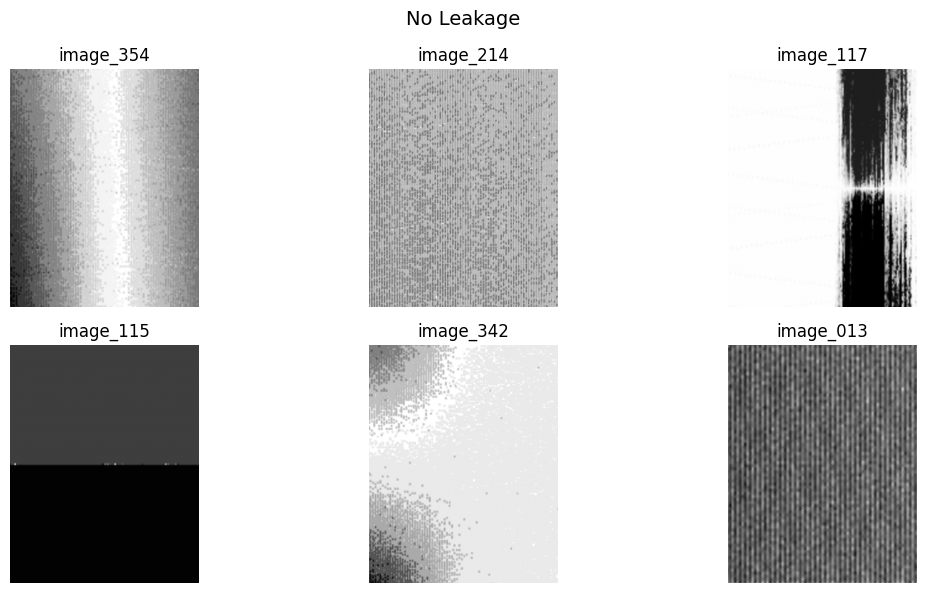

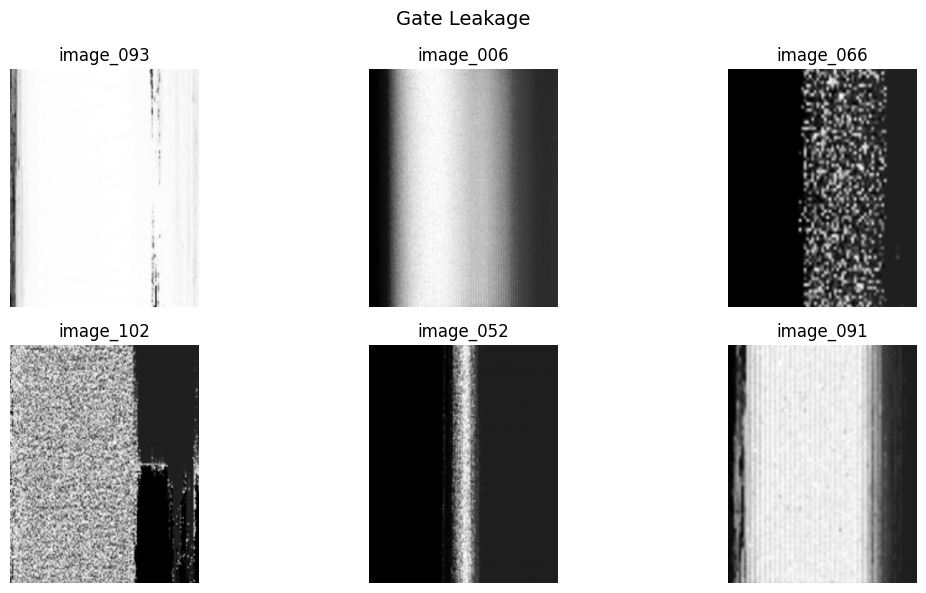

In [8]:
for label in [0, 1]:
    examples = mapping_df[mapping_df["leakage"] == label].sample(
        min(6, (mapping_df["leakage"] == label).sum()),
        random_state=42
    )

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, examples.iterrows()):
        img = Image.open(
            f"../data/processed/{row['image_id']}.png"
        )

        ax.imshow(img, cmap="gray")
        ax.set_title(row["image_id"])
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    plt.suptitle(
        "No Leakage" if label == 0 else "Gate Leakage",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

# Simple physics inspired baseline model

In [10]:
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "image_mapping.csv")
df.head()

,image_id,original_filename,leakage
0,image_001,100700_TEVP_10_IVsVg_b1.png,0
1,image_002,100802_TEVP_10_IVsVg_b2.png,0
2,image_003,100903_TEVP_10_IVsVg_b3.png,0
3,image_004,101004_TEVP_10_IVsVg_b4.png,0
4,image_005,101105_TEVP_10_IVsVg_b5.png,0


In [11]:
def load_image(image_id: str) -> np.ndarray:
    path = PROCESSED_DIR / f"{image_id}.png"
    img = Image.open(path)
    return np.array(img.convert("L"), dtype=np.float32)

In [12]:
images = np.stack([load_image(image_id) for image_id in df["image_id"]])

labels = df["leakage"].to_numpy()

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (375, 665, 525)
Labels: (375,)


A clear feature is the persistence of a blob of colour extending from either negative part to positive, or positive to negative, which corresponds to the gate voltage in charge of current direction instead of the source and drain voltage

In [22]:
def horizontal_gradient(image: np.ndarray) -> np.ndarray:
    return np.abs(np.diff(image, axis=1))

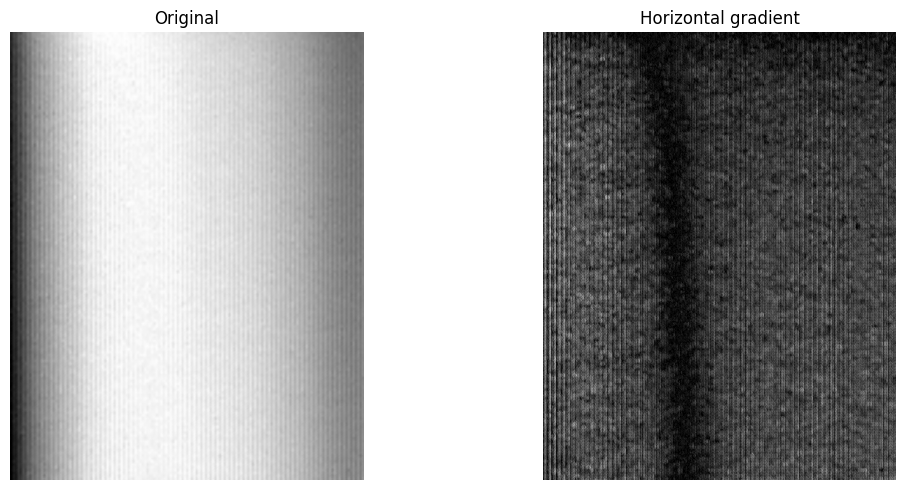

In [38]:
image = images[0]

gradient = horizontal_gradient(image)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gradient, cmap="gray")
axes[1].set_title("Horizontal gradient")
axes[1].axis("off")

plt.tight_layout()

In [24]:
def vertical_persistence_score(image, percentile=90):
    gradient = horizontal_gradient(image)

    threshold = np.percentile(gradient, percentile)

    strong = gradient >= threshold

    # Fraction of rows in which each x position has a strong response
    persistence = strong.mean(axis=0)

    return persistence

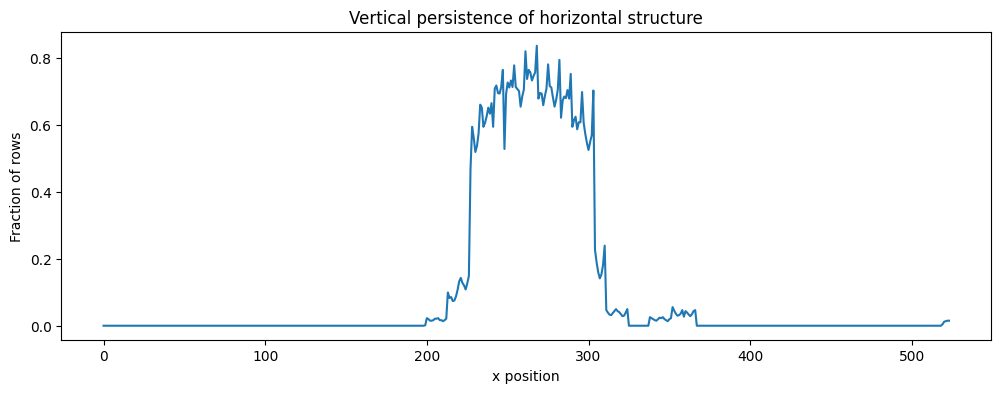

In [26]:
persistence = vertical_persistence_score(images[20])

plt.figure(figsize=(12, 4))
plt.plot(persistence)
plt.xlabel("x position")
plt.ylabel("Fraction of rows")
plt.title("Vertical persistence of horizontal structure")
plt.show()

In [32]:
scores = np.array([
    vertical_persistence_score(image).max()
    for image in images
])

df["vertical_persistence"] = scores

df.groupby("leakage")["vertical_persistence"].describe()

,count,mean,std,min,25%,50%,75%,max
leakage,,,,,,,,
0,295.0,0.863041,0.163977,0.218045,0.800752,0.915789,1.0,1.0
1,80.0,0.926053,0.150339,0.296241,0.940977,0.991729,1.0,1.0


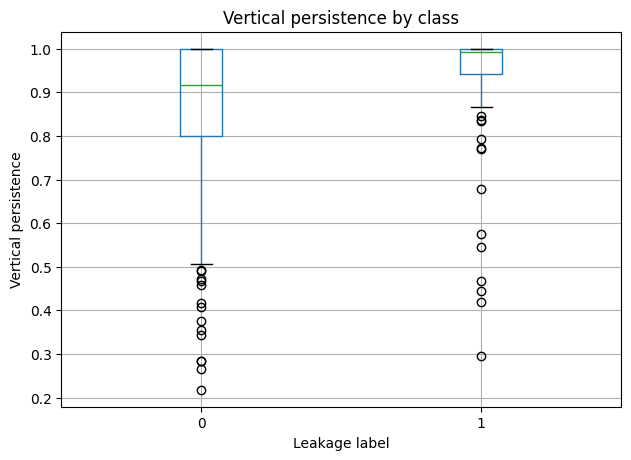

In [33]:
df.boxplot(
    column="vertical_persistence",
    by="leakage",
    figsize=(7, 5)
)

plt.title("Vertical persistence by class")
plt.suptitle("")
plt.xlabel("Leakage label")
plt.ylabel("Vertical persistence")
plt.show()

In [37]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    df["leakage"],
    df["vertical_persistence"]
)

print(f"ROC-AUC: {auc:.3f}")

auc_inverted = roc_auc_score(
    df["leakage"],
    -df["vertical_persistence"]
)

print(f"Inverted ROC-AUC: {auc_inverted:.3f}")

ROC-AUC: 0.642
Inverted ROC-AUC: 0.358


We observe the vertical persistence of a feature is more concentrated around 1 for leakage devices, however, it's not enough to separate the two, as there are always some vertical streak in the normal device, which is mostly due to experimental artefact (mostly due to the resolution of the gate voltage during measurement)

Nevertheless, we can see that the physics inspired model follows our intuition, and indeed vertical streak allows us to differentiate some of the samples. Therefore, it serves as a decent baseline model, with an ROC-AUC of 0.642

### A better physics inspired model

In [100]:
from skimage.filters import threshold_otsu

In [103]:
def leakage_persistence_score(image_path, center_fraction=0.02):

    image = np.array(
        Image.open(image_path).convert("L"),
        dtype=np.float32
    )

    # Darkness: 0 = white, 1 = black
    darkness = 1.0 - image / 255.0

    height, width = darkness.shape

    # Narrow band around V_SD = 0
    center_band = max(3, int(center_fraction * height))

    center_start = height // 2 - center_band // 2
    center_end = center_start + center_band

    top = darkness[:center_start, :]
    center = darkness[center_start:center_end, :]
    bottom = darkness[center_end:, :]

    # Median darkness at each x-position
    top_darkness = np.median(top, axis=0)
    center_darkness = np.median(center, axis=0)
    bottom_darkness = np.median(bottom, axis=0)

    # Leakage should be dark in all three regions
    persistence = np.minimum.reduce([
        top_darkness,
        center_darkness,
        bottom_darkness
    ])

    return persistence.max()

In [107]:
def leakage_ratio_score(
    image_path,
    center_fraction=0.02,
    darkness_threshold=0.3,
    eps=1e-6
):
    image = np.array(
        Image.open(image_path).convert("L"),
        dtype=np.float32
    )

    darkness = 1.0 - image / 255.0

    height, width = darkness.shape

    center_band = max(3, int(center_fraction * height))

    center_start = height // 2 - center_band // 2
    center_end = center_start + center_band

    top = darkness[:center_start, :]
    center = darkness[center_start:center_end, :]
    bottom = darkness[center_end:, :]

    D_top = np.median(top, axis=0)
    D_center = np.median(center, axis=0)
    D_bottom = np.median(bottom, axis=0)

    surrounding_darkness = np.minimum(D_top, D_bottom)

    valid = surrounding_darkness > darkness_threshold

    ratio = np.zeros_like(D_center)

    ratio[valid] = (
        D_center[valid]
        / (surrounding_darkness[valid] + eps)
    )

    if not np.any(valid):
        return 0.0

    return ratio[valid].max()

In [109]:
center_fractions = [0.01, 0.02, 0.03, 0.05]
darkness_thresholds = [0.2, 0.3, 0.4, 0.5]

results = []

for center_fraction in center_fractions:
    for threshold in darkness_thresholds:

        scores = []

        for _, row in val_df.iterrows():

            image_path = (
                Path("../data/processed")
                / f"{row['image_id']}.png"
            )

            score = leakage_ratio_score(
                image_path,
                center_fraction=center_fraction,
                darkness_threshold=threshold
            )

            scores.append(score)

        auc = roc_auc_score(
            val_df["leakage"],
            scores
        )

        results.append({
            "center_fraction": center_fraction,
            "darkness_threshold": threshold,
            "val_roc_auc": auc
        })

results_df = (
    pd.DataFrame(results)
    .sort_values("val_roc_auc", ascending=False)
    .reset_index(drop=True)
)

results_df

,center_fraction,darkness_threshold,val_roc_auc
0,0.01,0.3,0.927083
1,0.01,0.4,0.927083
2,0.01,0.5,0.923295
3,0.01,0.2,0.920455
4,0.05,0.5,0.919508
5,0.05,0.4,0.919508
6,0.02,0.5,0.917614
7,0.03,0.5,0.917614
8,0.05,0.3,0.916667
9,0.03,0.3,0.915720


In [110]:
best_center_fraction = 0.01
best_darkness_threshold = 0.3

test_physics_scores = []

for _, row in test_df.iterrows():

    image_path = (
        Path("../data/processed")
        / f"{row['image_id']}.png"
    )

    score = leakage_ratio_score(
        image_path,
        center_fraction=best_center_fraction,
        darkness_threshold=best_darkness_threshold
    )

    test_physics_scores.append(score)

test_physics_auc = roc_auc_score(
    test_df["leakage"],
    test_physics_scores
)

print(f"Physics baseline test ROC-AUC: {test_physics_auc:.4f}")

Physics baseline test ROC-AUC: 0.9167


# CNN method

We begin by using the ResNet18 and only train the final output layer, this should be computationally light and works well with my CPU only hardware limit

Split the data first to training, test, and validation. We stratify the data for the split to ensure the three splits satisfy the imbalanced status of our dataset

In [40]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["leakage"],
    random_state=42
)

val_df, test_df = train_test_split(
    test_df,
    test_size=0.5,
    stratify=test_df["leakage"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class counts:")
print(train_df["leakage"].value_counts())

print("\nValidation class counts:")
print(val_df["leakage"].value_counts())

print("\nTest class counts:")
print(test_df["leakage"].value_counts())

Train: 262
Validation: 56
Test: 57

Train class counts:
leakage
0    206
1     56
Name: count, dtype: int64

Validation class counts:
leakage
0    44
1    12
Name: count, dtype: int64

Test class counts:
leakage
0    45
1    12
Name: count, dtype: int64


### Constructing the data loader

In [41]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [47]:
class LeakageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = self.image_dir / f"{row['image_id']}.png"

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["leakage"], dtype=torch.float32)

        return image, label

In [48]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

In [49]:
IMAGE_DIR = Path("../data/processed")

train_dataset = LeakageDataset(
    train_df,
    IMAGE_DIR,
    transform=train_transform
)

val_dataset = LeakageDataset(
    val_df,
    IMAGE_DIR,
    transform=eval_transform
)

test_dataset = LeakageDataset(
    test_df,
    IMAGE_DIR,
    transform=eval_transform
)

In [50]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [51]:
images_batch, labels_batch = next(iter(train_loader))

print("Image batch:", images_batch.shape)
print("Labels:", labels_batch.shape)
print("Pixel range:", images_batch.min().item(), images_batch.max().item())
print("Labels:", labels_batch)

Image batch: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Pixel range: 0.03529411926865578 0.9960784316062927
Labels: tensor([0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1.])


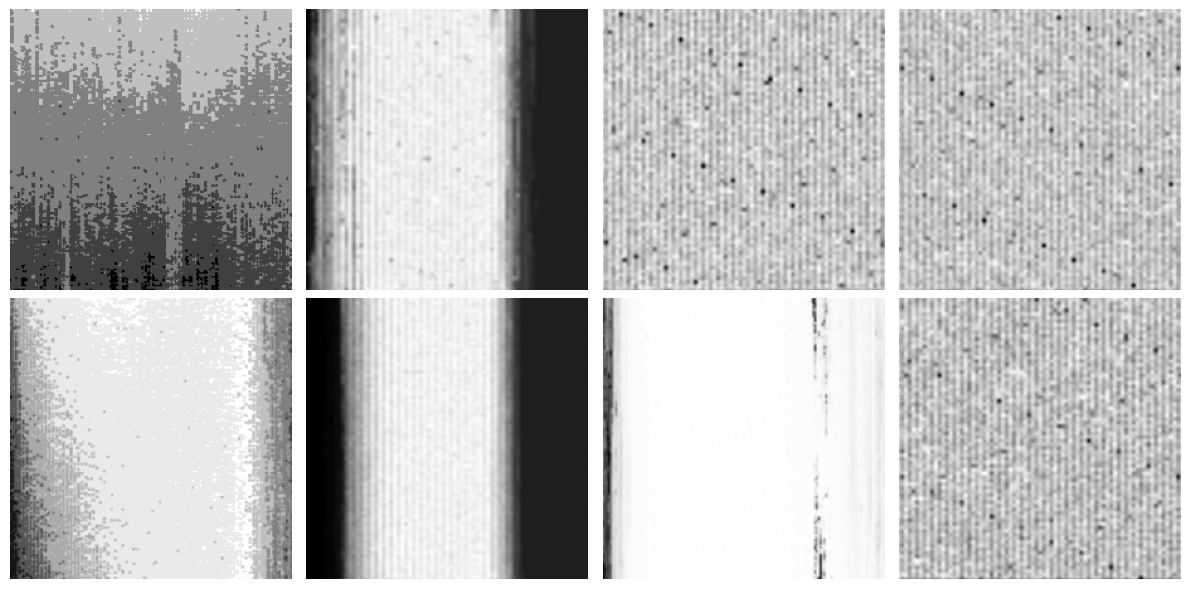

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image in zip(axes.flat, images_batch[:8]):
    ax.imshow(image[0], cmap="gray")
    ax.axis("off")

plt.tight_layout()

### Train the model

In [64]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 1)

Device: cpu


In [65]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [66]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 513
Total parameters: 11,177,025


In [67]:
num_negative = (train_df["leakage"] == 0).sum()
num_positive = (train_df["leakage"] == 1).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32,
    device=device
)

print("Positive class weight:", pos_weight.item())

Positive class weight: 3.6785714626312256


In [68]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [69]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [70]:
NUM_EPOCHS = 15

In [71]:
def evaluate(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    auc = roc_auc_score(all_labels, all_probs)

    return auc

In [72]:
for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images).squeeze(1)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader)

    val_auc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Val ROC-AUC: {val_auc:.3f}"
    )

Epoch 01/15 | Loss: 16.9664 | Val ROC-AUC: 0.472
Epoch 02/15 | Loss: 13.6596 | Val ROC-AUC: 0.712
Epoch 03/15 | Loss: 11.8894 | Val ROC-AUC: 0.913
Epoch 04/15 | Loss: 10.7407 | Val ROC-AUC: 0.922
Epoch 05/15 | Loss: 10.0682 | Val ROC-AUC: 0.945
Epoch 06/15 | Loss: 9.1051 | Val ROC-AUC: 0.989
Epoch 07/15 | Loss: 9.5429 | Val ROC-AUC: 0.983
Epoch 08/15 | Loss: 8.3989 | Val ROC-AUC: 0.989
Epoch 09/15 | Loss: 7.6580 | Val ROC-AUC: 0.991
Epoch 10/15 | Loss: 7.7851 | Val ROC-AUC: 0.987
Epoch 11/15 | Loss: 8.6303 | Val ROC-AUC: 0.992
Epoch 12/15 | Loss: 7.2332 | Val ROC-AUC: 0.992
Epoch 13/15 | Loss: 7.4808 | Val ROC-AUC: 0.989
Epoch 14/15 | Loss: 7.0346 | Val ROC-AUC: 0.994
Epoch 15/15 | Loss: 6.4227 | Val ROC-AUC: 0.996


In [74]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [75]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Convert probabilities to class predictions
all_preds = (all_probs >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Test ROC-AUC:  {roc_auc:.4f}")
print(f"Test PR-AUC:   {pr_auc:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1:            {f1:.4f}")

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["No leakage", "Leakage"]
))

Test ROC-AUC:  0.9204
Test PR-AUC:   0.7986
Precision:     0.6667
Recall:        0.8333
F1:            0.7407

Confusion matrix:
[[40  5]
 [ 2 10]]

Classification report:
              precision    recall  f1-score   support

  No leakage       0.95      0.89      0.92        45
     Leakage       0.67      0.83      0.74        12

    accuracy                           0.88        57
   macro avg       0.81      0.86      0.83        57
weighted avg       0.89      0.88      0.88        57



In [76]:
# Add predictions to a copy of the test dataframe
test_results = test_df.copy().reset_index(drop=True)

test_results["probability"] = all_probs
test_results["prediction"] = all_preds

# False negatives: actual leakage, predicted no leakage
false_negatives = test_results[
    (test_results["leakage"] == 1) &
    (test_results["prediction"] == 0)
]

# False positives: actual no leakage, predicted leakage
false_positives = test_results[
    (test_results["leakage"] == 0) &
    (test_results["prediction"] == 1)
]

print("False negatives:")
print(false_negatives[["image_id", "leakage", "probability"]])

print("\nFalse positives:")
print(false_positives[["image_id", "leakage", "probability"]])

False negatives:
     image_id  leakage  probability
11  image_219        1     0.289017
24  image_092        1     0.063625

False positives:
     image_id  leakage  probability
9   image_133        0     0.848507
33  image_083        0     0.744131
35  image_011        0     0.572233
42  image_361        0     0.508769
50  image_128        0     0.941911


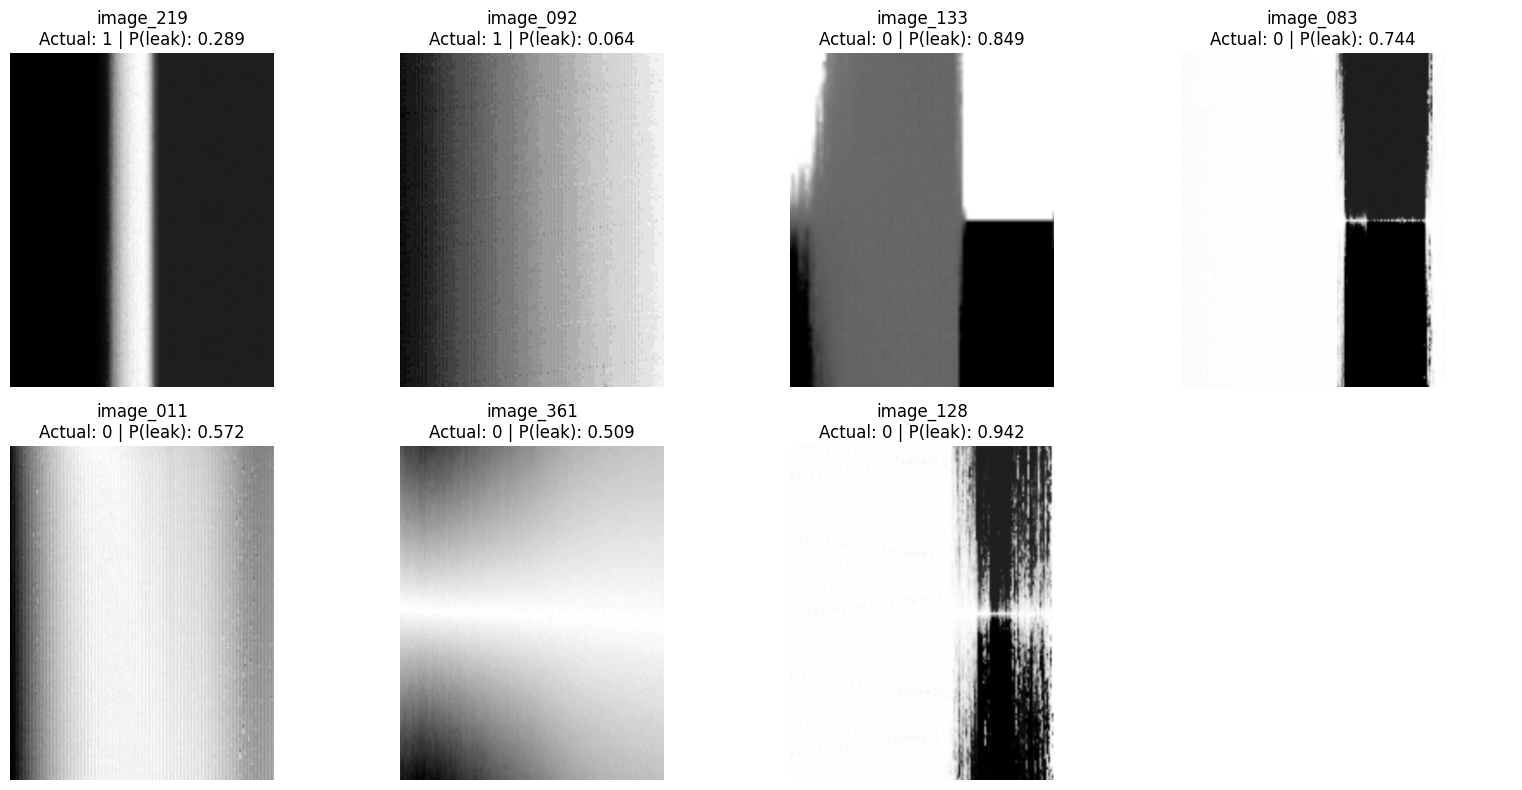

In [78]:
mistake_ids = [
    "image_219",
    "image_092",
    "image_133",
    "image_083",
    "image_011",
    "image_361",
    "image_128",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, image_id in zip(axes, mistake_ids):
    image_path = Path("../data/processed") / f"{image_id}.png"
    image = Image.open(image_path)

    row = test_results[test_results["image_id"] == image_id].iloc[0]

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{image_id}\n"
        f"Actual: {row['leakage']} | "
        f"P(leak): {row['probability']:.3f}"
    )
    ax.axis("off")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

Having visualised the false positives and false negatives, it seems that the model is not yet able to differentiate the distinguishing features of leakage, that is same dominant colour across the entire vertical, whereas any dominant colour patch but stops at roughly the middle is normal feature and not leakage

In [79]:
def grad_cam(model, image_path, transform, device):
    model.eval()

    # Load image
    image = Image.open(image_path).convert("L")

    # Apply exactly the same preprocessing used during evaluation
    input_tensor = transform(image).unsqueeze(0).to(device)

    # We need gradients with respect to the feature maps.
    input_tensor.requires_grad_(True)

    # ResNet18's final convolutional block
    target_layer = model.layer4[-1]

    activations = {}

    def forward_hook(module, input, output):
        activations["value"] = output
        output.retain_grad()

    hook = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    model.zero_grad()

    output = model(input_tensor)
    logit = output.squeeze()

    # Backpropagate the leakage score
    logit.backward()

    # Get feature maps and gradients
    feature_maps = activations["value"].detach()
    gradients = activations["value"].grad.detach()

    # Remove batch dimension
    feature_maps = feature_maps[0]
    gradients = gradients[0]

    # Global average pooling of gradients
    weights = gradients.mean(dim=(1, 2))

    # Weighted combination of feature maps
    cam = torch.zeros(
        feature_maps.shape[1:],
        device=device
    )

    for i, weight in enumerate(weights):
        cam += weight * feature_maps[i]

    # ReLU: keep regions that positively contribute to leakage
    cam = torch.relu(cam)

    # Normalize
    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    cam = cam.cpu().numpy()

    # Remove hook
    hook.remove()

    probability = torch.sigmoid(logit).item()

    return image, cam, probability

In [80]:
image_id = "image_128"

image_path = Path("../data/processed") / f"{image_id}.png"

image, cam, probability = grad_cam(
    model,
    image_path,
    eval_transform,
    device
)

print(f"{image_id}")
print(f"Model P(leakage): {probability:.3f}")

image_128
Model P(leakage): 0.942


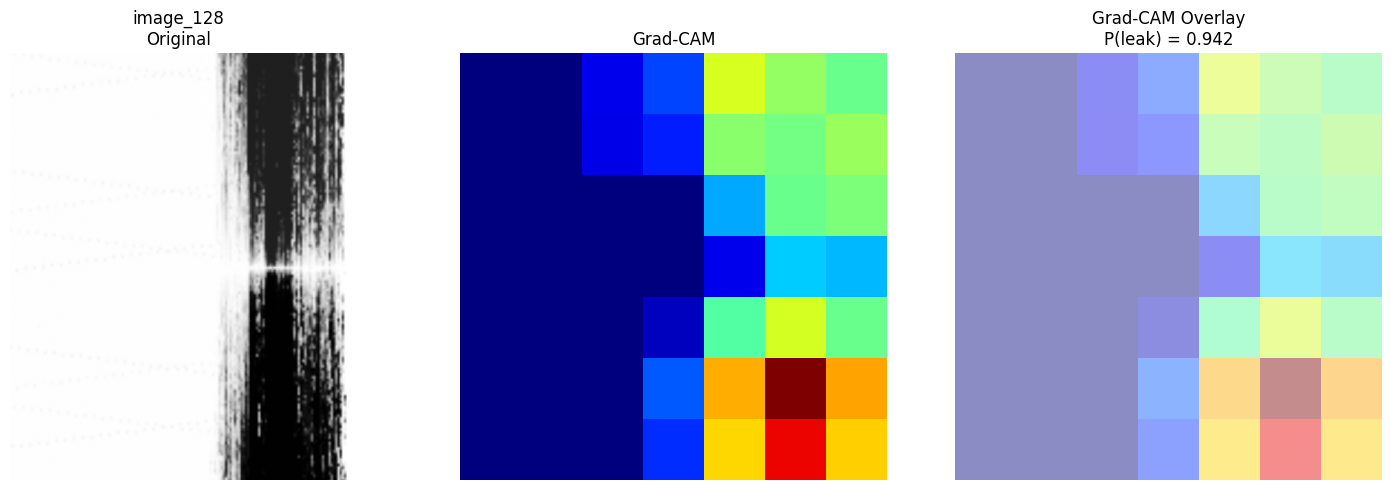

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"{image_id}\nOriginal")
axes[0].axis("off")

# Grad-CAM
axes[1].imshow(cam, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

# Overlay
axes[2].imshow(image, cmap="gray")
axes[2].imshow(
    cam,
    cmap="jet",
    alpha=0.45
)
axes[2].set_title(
    f"Grad-CAM Overlay\nP(leak) = {probability:.3f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

Grad-CAM reveals that the model is looking at the right place, but not treating both patches equally, which should be the cue to tell that this is not leakage

In [86]:
import torch.nn.functional as F

def grad_cam(model, image_path, transform, device):
    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert("L")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # IMPORTANT:
    # Force a computation graph through the frozen backbone
    input_tensor.requires_grad_(True)

    target_layer = model.layer4[-1]

    activations = {}

    def forward_hook(module, input, output):
        activations["value"] = output
        output.retain_grad()

    hook = target_layer.register_forward_hook(forward_hook)

    # Forward pass WITH gradients
    model.zero_grad()

    output = model(input_tensor)
    logit = output.squeeze()

    # Backpropagate leakage score
    logit.backward()

    # Retrieve activations and their gradients
    feature_maps = activations["value"].detach()[0]
    gradients = activations["value"].grad.detach()[0]

    # Global average pooling of gradients
    weights = gradients.mean(dim=(1, 2))

    # Weighted feature maps
    cam = torch.sum(
        weights[:, None, None] * feature_maps,
        dim=0
    )

    # Keep only positive contribution to leakage
    cam = torch.relu(cam)

    # Upsample to input image size
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=input_tensor.shape[-2:],
        mode="bilinear",
        align_corners=False
    ).squeeze()

    # Normalize
    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    cam = cam.cpu().numpy()

    probability = torch.sigmoid(logit).item()

    hook.remove()

    return image, cam, probability

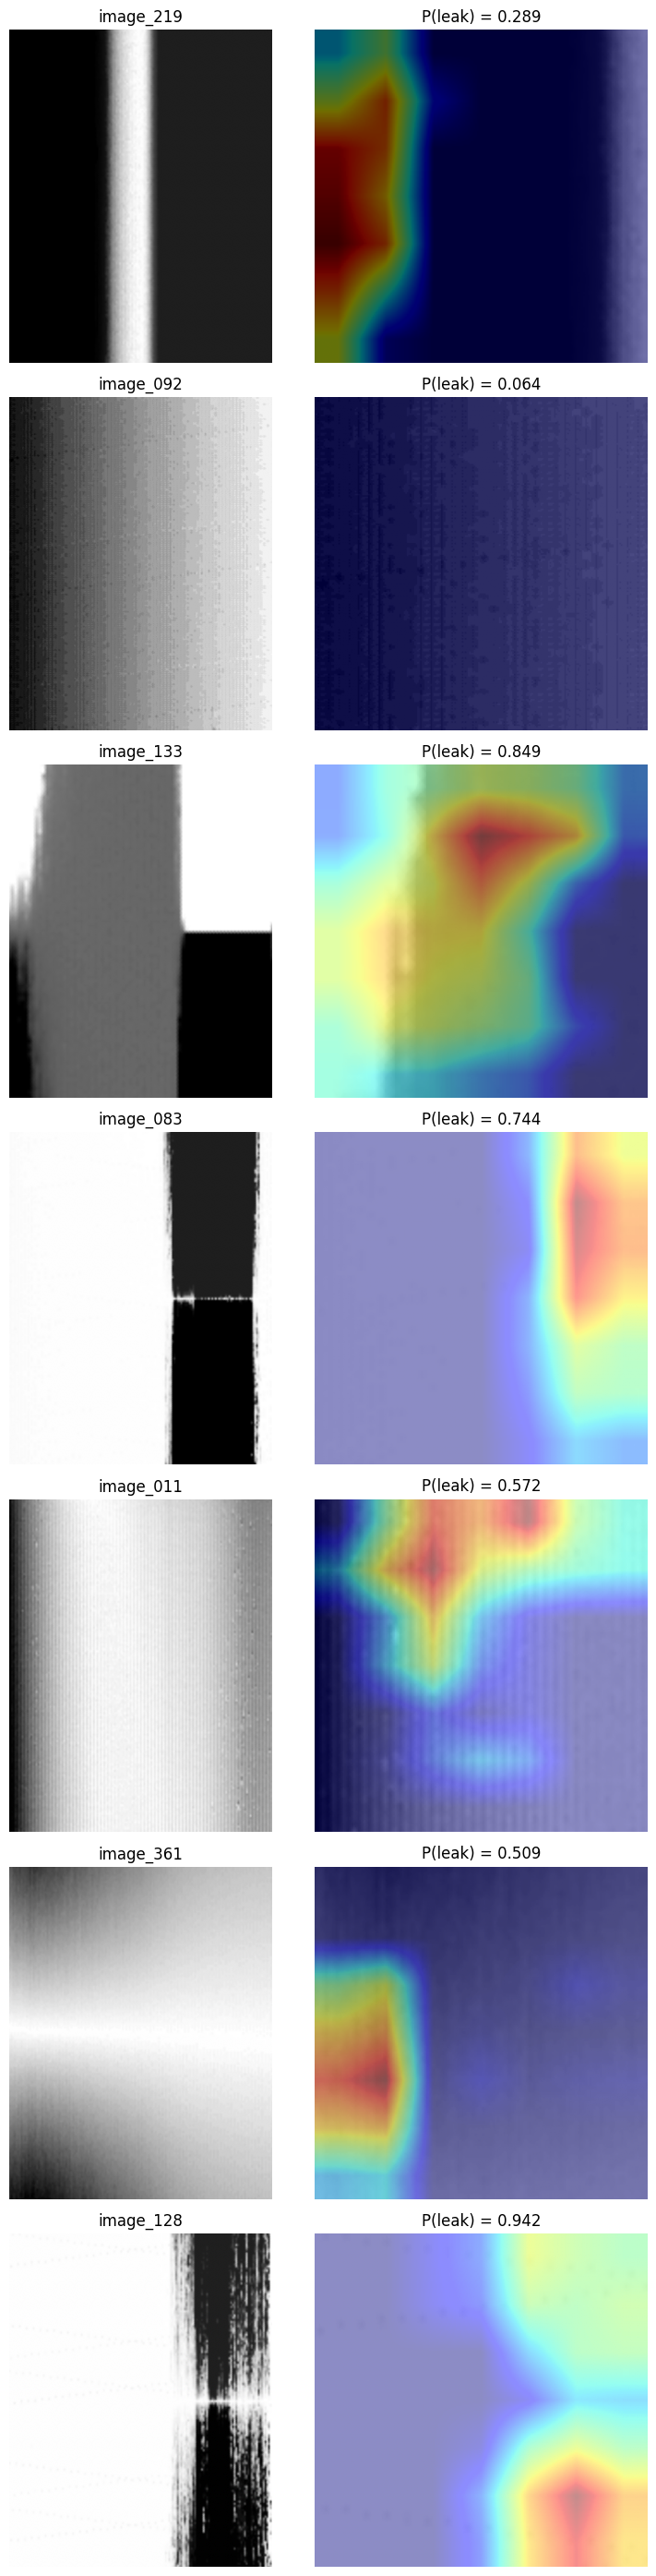

In [89]:
mistake_ids = [
    "image_219",
    "image_092",
    "image_133",
    "image_083",
    "image_011",
    "image_361",
    "image_128",
]

fig, axes = plt.subplots(
    len(mistake_ids),
    2,
    figsize=(8, 4 * len(mistake_ids))
)

for row_idx, image_id in enumerate(mistake_ids):

    image_path = Path("../data/processed") / f"{image_id}.png"

    image, cam, probability = grad_cam(
        model,
        image_path,
        eval_transform,
        device
    )

    # Original + CAM overlay
    axes[row_idx, 0].imshow(image, cmap="gray")
    axes[row_idx, 0].set_title(image_id)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(image, cmap="gray")
    axes[row_idx, 1].imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )
    axes[row_idx, 1].set_title(
        f"P(leak) = {probability:.3f}"
    )
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

### Unfrozen layer 4 to train

In [90]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Fresh ImageNet-pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model_ft = resnet18(weights=weights)

# Replace ImageNet classifier with binary classifier
model_ft.fc = nn.Linear(model_ft.fc.in_features, 1)

# Freeze everything
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze the final convolutional block
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model_ft.fc.parameters():
    param.requires_grad = True

model_ft = model_ft.to(device)

In [91]:
trainable_params = sum(
    p.numel()
    for p in model_ft.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model_ft.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 8,394,241
Total parameters: 11,177,025


In [92]:
num_negative = (train_df["leakage"] == 0).sum()
num_positive = (train_df["leakage"] == 1).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    [
        {
            "params": model_ft.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model_ft.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-4
)

print(f"Positive class weight: {pos_weight.item():.3f}")

Positive class weight: 3.679


In [93]:
from sklearn.metrics import roc_auc_score
import copy

num_epochs = 15

best_val_auc = 0.0
best_state = None

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model_ft.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_ft(images).squeeze(1)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # -------------------------
    # Validation
    # -------------------------
    model_ft.eval()

    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model_ft(images).squeeze(1)
            probs = torch.sigmoid(outputs)

            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Val ROC-AUC: {val_auc:.3f}"
    )

    # Save best validation model
    if val_auc > best_val_auc:

        best_val_auc = val_auc

        best_state = copy.deepcopy(
            model_ft.state_dict()
        )

print(f"\nBest validation ROC-AUC: {best_val_auc:.4f}")

Epoch 01/15 | Loss: 0.6826 | Val ROC-AUC: 0.945
Epoch 02/15 | Loss: 0.2748 | Val ROC-AUC: 0.991
Epoch 03/15 | Loss: 0.1405 | Val ROC-AUC: 0.996
Epoch 04/15 | Loss: 0.1162 | Val ROC-AUC: 0.996
Epoch 05/15 | Loss: 0.0592 | Val ROC-AUC: 0.998
Epoch 06/15 | Loss: 0.1199 | Val ROC-AUC: 0.998
Epoch 07/15 | Loss: 0.0755 | Val ROC-AUC: 1.000
Epoch 08/15 | Loss: 0.0637 | Val ROC-AUC: 0.998
Epoch 09/15 | Loss: 0.0300 | Val ROC-AUC: 0.998
Epoch 10/15 | Loss: 0.0256 | Val ROC-AUC: 0.998
Epoch 11/15 | Loss: 0.0257 | Val ROC-AUC: 0.998
Epoch 12/15 | Loss: 0.0132 | Val ROC-AUC: 1.000
Epoch 13/15 | Loss: 0.0149 | Val ROC-AUC: 1.000
Epoch 14/15 | Loss: 0.0384 | Val ROC-AUC: 0.994
Epoch 15/15 | Loss: 0.0704 | Val ROC-AUC: 0.998

Best validation ROC-AUC: 1.0000


In [94]:
model_ft.load_state_dict(best_state)
model_ft.eval()

print(f"Using model with validation ROC-AUC = {best_val_auc:.4f}")

Using model with validation ROC-AUC = 1.0000


In [95]:
model_ft.eval()

test_labels = []
test_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_ft(images).squeeze(1)
        probs = torch.sigmoid(outputs)

        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.numpy())

test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

test_preds = (test_probs >= 0.5).astype(int)

roc_auc = roc_auc_score(test_labels, test_probs)
pr_auc = average_precision_score(test_labels, test_probs)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
cm = confusion_matrix(test_labels, test_preds)

print(f"Test ROC-AUC:  {roc_auc:.4f}")
print(f"Test PR-AUC:   {pr_auc:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1:            {f1:.4f}")

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["No leakage", "Leakage"]
))

Test ROC-AUC:  0.9833
Test PR-AUC:   0.9643
Precision:     0.9167
Recall:        0.9167
F1:            0.9167

Confusion matrix:
[[44  1]
 [ 1 11]]

Classification report:
              precision    recall  f1-score   support

  No leakage       0.98      0.98      0.98        45
     Leakage       0.92      0.92      0.92        12

    accuracy                           0.96        57
   macro avg       0.95      0.95      0.95        57
weighted avg       0.96      0.96      0.96        57



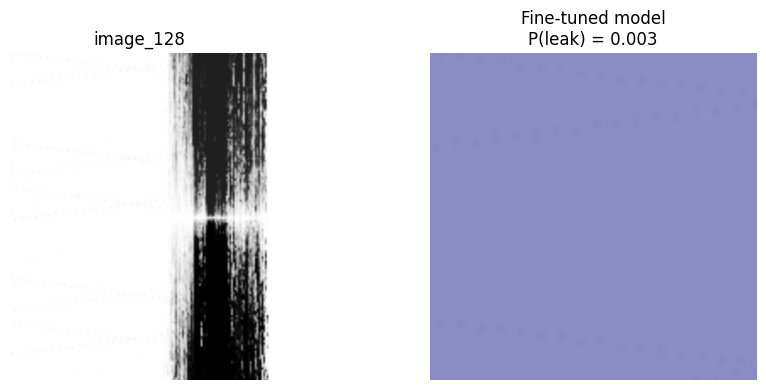

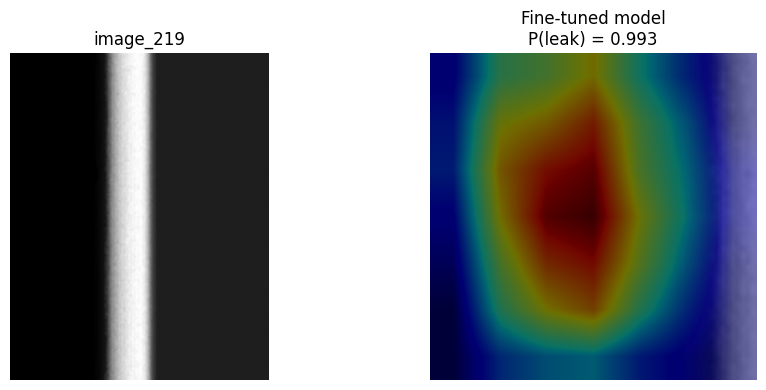

In [96]:
for image_id in ["image_128", "image_219"]:

    image_path = Path("../data/processed") / f"{image_id}.png"

    image, cam, probability = grad_cam(
        model_ft,
        image_path,
        eval_transform,
        device
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title(image_id)
    axes[0].axis("off")

    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(cam, cmap="jet", alpha=0.45)
    axes[1].set_title(
        f"Fine-tuned model\nP(leak) = {probability:.3f}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Evaluate the three methods

In [111]:
def evaluate_scores(y_true, scores, threshold=0.5):
    y_pred = (np.array(scores) >= threshold).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

In [114]:
physics_results = evaluate_scores(
    test_df["leakage"].values,
    test_physics_scores
)

physics_results

{'ROC-AUC': 0.9166666666666667,
 'PR-AUC': 0.6374262311762312,
 'Precision': 0.375,
 'Recall': 1.0,
 'F1': 0.5454545454545454,
 'Confusion Matrix': array([[25, 20],
        [ 0, 12]])}

In [121]:
y_test_cnn, frozen_scores = get_model_scores(
    model,
    test_loader
)

In [116]:
model_ft.load_state_dict(best_state)

<All keys matched successfully>

In [117]:
y_test_ft, finetuned_scores = get_model_scores(
    model_ft,
    test_loader
)

finetuned_results = evaluate_scores(
    y_test_ft,
    finetuned_scores
)

finetuned_results

{'ROC-AUC': 0.9833333333333334,
 'PR-AUC': 0.9642857142857143,
 'Precision': 0.9166666666666666,
 'Recall': 0.9166666666666666,
 'F1': 0.9166666666666666,
 'Confusion Matrix': array([[44,  1],
        [ 1, 11]])}

In [123]:
comparison = pd.DataFrame({
    "Physics baseline": {
        "ROC-AUC": roc_auc_score(test_df["leakage"], test_physics_scores),
        "PR-AUC": average_precision_score(test_df["leakage"], test_physics_scores),
        "Precision": precision_score(
            test_df["leakage"],
            np.array(test_physics_scores) >= 0.5
        ),
        "Recall": recall_score(
            test_df["leakage"],
            np.array(test_physics_scores) >= 0.5
        ),
        "F1": f1_score(
            test_df["leakage"],
            np.array(test_physics_scores) >= 0.5
        ),
    },

    "Frozen ResNet18": {
        "ROC-AUC": roc_auc_score(y_test_cnn, frozen_scores),
        "PR-AUC": average_precision_score(y_test_cnn, frozen_scores),
        "Precision": precision_score(
            y_test_cnn,
            frozen_scores >= 0.5
        ),
        "Recall": recall_score(
            y_test_cnn,
            frozen_scores >= 0.5
        ),
        "F1": f1_score(
            y_test_cnn,
            frozen_scores >= 0.5
        ),
    },

    "Fine-tuned ResNet18": {
        "ROC-AUC": roc_auc_score(y_test_ft, finetuned_scores),
        "PR-AUC": average_precision_score(y_test_ft, finetuned_scores),
        "Precision": precision_score(
            y_test_ft,
            finetuned_scores >= 0.5
        ),
        "Recall": recall_score(
            y_test_ft,
            finetuned_scores >= 0.5
        ),
        "F1": f1_score(
            y_test_ft,
            finetuned_scores >= 0.5
        ),
    }
}).round(4)

comparison

,Physics baseline,Frozen ResNet18,Fine-tuned ResNet18
ROC-AUC,0.9167,0.9204,0.9833
PR-AUC,0.6374,0.7986,0.9643
Precision,0.3750,0.6667,0.9167
Recall,1.0000,0.8333,0.9167
F1,0.5455,0.7407,0.9167


In [124]:
print("Physics baseline")
print(confusion_matrix(
    test_df["leakage"],
    np.array(test_physics_scores) >= 0.5
))

print("\nFrozen ResNet18")
print(confusion_matrix(
    y_test_cnn,
    frozen_scores >= 0.5
))

print("\nFine-tuned ResNet18")
print(confusion_matrix(
    y_test_ft,
    finetuned_scores >= 0.5
))

Physics baseline
[[25 20]
 [ 0 12]]

Frozen ResNet18
[[40  5]
 [ 2 10]]

Fine-tuned ResNet18
[[44  1]
 [ 1 11]]


In [125]:
from sklearn.metrics import f1_score


def find_best_threshold(y_true, scores):
    thresholds = np.linspace(0, 1, 1001)

    f1_scores = []

    for threshold in thresholds:
        predictions = (scores >= threshold).astype(int)
        f1_scores.append(
            f1_score(y_true, predictions, zero_division=0)
        )

    best_idx = np.argmax(f1_scores)

    return thresholds[best_idx], f1_scores[best_idx]

In [126]:
y_val_cnn, frozen_val_scores = get_model_scores(
    model,
    val_loader
)

y_val_ft, finetuned_val_scores = get_model_scores(
    model_ft,
    val_loader
)

In [127]:
val_physics_scores = []

for _, row in val_df.iterrows():
    image_path = Path("../data/processed") / f"{row['image_id']}.png"

    score = leakage_ratio_score(
        image_path,
        center_fraction=best_center_fraction,
        darkness_threshold=best_darkness_threshold
    )

    val_physics_scores.append(score)

val_physics_scores = np.array(val_physics_scores)
y_val_physics = val_df["leakage"].values

In [128]:
physics_threshold, physics_val_f1 = find_best_threshold(
    y_val_physics,
    val_physics_scores
)

frozen_threshold, frozen_val_f1 = find_best_threshold(
    y_val_cnn,
    frozen_val_scores
)

finetuned_threshold, finetuned_val_f1 = find_best_threshold(
    y_val_ft,
    finetuned_val_scores
)

print(f"Physics threshold:       {physics_threshold:.3f} "
      f"(validation F1 = {physics_val_f1:.3f})")

print(f"Frozen ResNet threshold: {frozen_threshold:.3f} "
      f"(validation F1 = {frozen_val_f1:.3f})")

print(f"Fine-tuned threshold:    {finetuned_threshold:.3f} "
      f"(validation F1 = {finetuned_val_f1:.3f})")

Physics threshold:       0.996 (validation F1 = 0.579)
Frozen ResNet threshold: 0.596 (validation F1 = 0.960)
Fine-tuned threshold:    0.488 (validation F1 = 1.000)


In [129]:
physics_test_pred = (
    np.array(test_physics_scores) >= physics_threshold
).astype(int)

frozen_test_pred = (
    frozen_scores >= frozen_threshold
).astype(int)

finetuned_test_pred = (
    finetuned_scores >= finetuned_threshold
).astype(int)

In [131]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

final_comparison = pd.DataFrame({
    "Physics baseline": {
        "ROC-AUC": roc_auc_score(
            test_df["leakage"],
            test_physics_scores
        ),
        "PR-AUC": average_precision_score(
            test_df["leakage"],
            test_physics_scores
        ),
        "Precision": precision_score(
            test_df["leakage"],
            physics_test_pred
        ),
        "Recall": recall_score(
            test_df["leakage"],
            physics_test_pred
        ),
        "F1": f1_score(
            test_df["leakage"],
            physics_test_pred
        ),
    },

    "Frozen ResNet18": {
        "ROC-AUC": roc_auc_score(
            y_test_cnn,
            frozen_scores
        ),
        "PR-AUC": average_precision_score(
            y_test_cnn,
            frozen_scores
        ),
        "Precision": precision_score(
            y_test_cnn,
            frozen_test_pred
        ),
        "Recall": recall_score(
            y_test_cnn,
            frozen_test_pred
        ),
        "F1": f1_score(
            y_test_cnn,
            frozen_test_pred
        ),
    },

    "Fine-tuned ResNet18": {
        "ROC-AUC": roc_auc_score(
            y_test_ft,
            finetuned_scores
        ),
        "PR-AUC": average_precision_score(
            y_test_ft,
            finetuned_scores
        ),
        "Precision": precision_score(
            y_test_ft,
            finetuned_test_pred
        ),
        "Recall": recall_score(
            y_test_ft,
            finetuned_test_pred
        ),
        "F1": f1_score(
            y_test_ft,
            finetuned_test_pred
        ),
    }
}).round(4)

final_comparison

,Physics baseline,Frozen ResNet18,Fine-tuned ResNet18
ROC-AUC,0.9167,0.9204,0.9833
PR-AUC,0.6374,0.7986,0.9643
Precision,0.4000,0.7692,0.9167
Recall,1.0000,0.8333,0.9167
F1,0.5714,0.8000,0.9167


In [133]:
print("Physics baseline")
print(confusion_matrix(
    test_df["leakage"],
    physics_test_pred
))

print("\nFrozen ResNet18")
print(confusion_matrix(
    y_test_cnn,
    frozen_test_pred
))

print("\nFine-tuned ResNet18")
print(confusion_matrix(
    y_test_ft,
    finetuned_test_pred
))

Physics baseline
[[27 18]
 [ 0 12]]

Frozen ResNet18
[[42  3]
 [ 2 10]]

Fine-tuned ResNet18
[[44  1]
 [ 1 11]]


The fine-tuned ResNet18 performs much better, however upon closer examination, the model does not seem to learn the key physical features expected when deciding whether there's leakage. I've decided to augment more training data

In [156]:
from torchvision import transforms

train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [157]:
import copy

train_dataset_flipped = copy.deepcopy(train_dataset)

train_dataset_flipped.transform = train_transform_aug

In [158]:
from torch.utils.data import ConcatDataset

train_dataset_combined = ConcatDataset([
    train_dataset,
    train_dataset_flipped
])

In [159]:
train_loader_aug = DataLoader(
    train_dataset_combined,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

In [161]:
from torchvision import models

model_ft_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace ImageNet 1000-class head
model_ft_aug.fc = nn.Linear(
    model_ft_aug.fc.in_features,
    1
)

# Freeze everything
for param in model_ft_aug.parameters():
    param.requires_grad = False

# Fine-tune layer4
for param in model_ft_aug.layer4.parameters():
    param.requires_grad = True

# Fine-tune classifier
for param in model_ft_aug.fc.parameters():
    param.requires_grad = True

print(
    "Trainable parameters:",
    sum(p.numel() for p in model_ft_aug.parameters()
        if p.requires_grad)
)

print(
    "Total parameters:",
    sum(p.numel() for p in model_ft_aug.parameters())
)

Trainable parameters: 8394241
Total parameters: 11177025


In [162]:
num_positive = (train_df["leakage"] == 1).sum()
num_negative = (train_df["leakage"] == 0).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [163]:
optimizer = torch.optim.AdamW(
    [
        {
            "params": model_ft_aug.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model_ft_aug.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-4
)

In [164]:
model_ft_aug = model_ft_aug.to(device)

num_epochs = 15

best_val_auc_aug = 0.0
best_state_aug = None

for epoch in range(num_epochs):

    # Training
    model_ft_aug.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        outputs = model_ft_aug(images).squeeze(1)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = (
        running_loss /
        len(train_loader_aug.dataset)
    )

    # Validation
    model_ft_aug.eval()

    val_scores = []
    val_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model_ft_aug(images).squeeze(1)

            probs = torch.sigmoid(outputs)

            val_scores.extend(
                probs.cpu().numpy()
            )

            val_labels.extend(
                labels.numpy()
            )

    val_auc = roc_auc_score(
        val_labels,
        val_scores
    )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val ROC-AUC: {val_auc:.4f}"
    )

    # Save best validation model
    if val_auc > best_val_auc_aug:

        best_val_auc_aug = val_auc

        best_state_aug = copy.deepcopy(
            model_ft_aug.state_dict()
        )

Epoch 01/15 | Train Loss: 0.5942 | Val ROC-AUC: 0.9886
Epoch 02/15 | Train Loss: 0.2572 | Val ROC-AUC: 0.9867
Epoch 03/15 | Train Loss: 0.2202 | Val ROC-AUC: 0.9981
Epoch 04/15 | Train Loss: 0.2704 | Val ROC-AUC: 1.0000
Epoch 05/15 | Train Loss: 0.1504 | Val ROC-AUC: 0.9962
Epoch 06/15 | Train Loss: 0.1493 | Val ROC-AUC: 1.0000
Epoch 07/15 | Train Loss: 0.1507 | Val ROC-AUC: 1.0000
Epoch 08/15 | Train Loss: 0.1504 | Val ROC-AUC: 1.0000
Epoch 09/15 | Train Loss: 0.0997 | Val ROC-AUC: 0.9981
Epoch 10/15 | Train Loss: 0.0737 | Val ROC-AUC: 1.0000
Epoch 11/15 | Train Loss: 0.0603 | Val ROC-AUC: 0.9981
Epoch 12/15 | Train Loss: 0.1208 | Val ROC-AUC: 0.9981
Epoch 13/15 | Train Loss: 0.0836 | Val ROC-AUC: 0.9962
Epoch 14/15 | Train Loss: 0.1245 | Val ROC-AUC: 0.9867
Epoch 15/15 | Train Loss: 0.0942 | Val ROC-AUC: 0.9943


In [165]:
model_ft_aug.load_state_dict(best_state_aug)

<All keys matched successfully>

In [166]:
y_test_aug, augmented_scores = get_model_scores(
    model_ft_aug,
    test_loader
)

In [167]:
augmented_roc_auc = roc_auc_score(
    y_test_aug,
    augmented_scores
)

augmented_pr_auc = average_precision_score(
    y_test_aug,
    augmented_scores
)

print(f"Augmented ROC-AUC: {augmented_roc_auc:.4f}")
print(f"Augmented PR-AUC:  {augmented_pr_auc:.4f}")

Augmented ROC-AUC: 0.9556
Augmented PR-AUC:  0.9444


In [169]:
comparison_aug = test_df[["image_id", "leakage"]].copy()

comparison_aug["original_prob"] = finetuned_scores
comparison_aug["augmented_prob"] = augmented_scores

comparison_aug["prob_change"] = (
    comparison_aug["augmented_prob"]
    - comparison_aug["original_prob"]
)

comparison_aug["abs_prob_change"] = (
    comparison_aug["prob_change"].abs()
)

comparison_aug["original_pred"] = (
    comparison_aug["original_prob"] >= 0.5
).astype(int)

comparison_aug["augmented_pred"] = (
    comparison_aug["augmented_prob"] >= 0.5
).astype(int)

comparison_aug["original_correct"] = (
    comparison_aug["original_pred"]
    == comparison_aug["leakage"]
)

comparison_aug["augmented_correct"] = (
    comparison_aug["augmented_pred"]
    == comparison_aug["leakage"]
)

In [171]:
comparison_aug.sort_values(
    "abs_prob_change",
    ascending=False
)[[
    "image_id",
    "leakage",
    "original_prob",
    "augmented_prob",
    "prob_change",
    "original_pred",
    "augmented_pred",
    "original_correct",
    "augmented_correct"
]].head(15)

,image_id,leakage,original_prob,augmented_prob,prob_change,original_pred,augmented_pred,original_correct,augmented_correct
127,image_128,0,0.002939,0.295620,0.292680,0,0,True,True
10,image_011,0,0.434461,0.723132,0.288671,0,1,True,False
1,image_002,0,0.306986,0.035726,-0.271260,0,0,True,True
312,image_313,0,0.032142,0.254178,0.222036,0,0,True,True
82,image_083,0,0.591900,0.395873,-0.196027,1,0,False,True
279,image_280,1,0.991627,0.806654,-0.184973,1,1,True,True
132,image_133,0,0.129125,0.248450,0.119326,0,0,True,True
252,image_253,1,0.973796,0.887238,-0.086558,1,1,True,True
360,image_361,0,0.063179,0.008760,-0.054419,0,0,True,True
56,image_057,1,0.956730,0.997114,0.040384,1,1,True,True


In [172]:
made_worse = comparison_aug[
    (comparison_aug["original_correct"] == True) &
    (comparison_aug["augmented_correct"] == False)
].sort_values(
    "abs_prob_change",
    ascending=False
)

made_worse

,image_id,leakage,original_prob,augmented_prob,prob_change,abs_prob_change,original_pred,augmented_pred,original_correct,augmented_correct
10,image_011,0,0.434461,0.723132,0.288671,0.288671,0,1,True,False


In [173]:
made_better = comparison_aug[
    (comparison_aug["original_correct"] == False) &
    (comparison_aug["augmented_correct"] == True)
].sort_values(
    "abs_prob_change",
    ascending=False
)

made_better

,image_id,leakage,original_prob,augmented_prob,prob_change,abs_prob_change,original_pred,augmented_pred,original_correct,augmented_correct
82,image_083,0,0.5919,0.395873,-0.196027,0.196027,1,0,False,True


In [174]:
print("Original mean probability:")
print(comparison_aug.groupby("leakage")["original_prob"].mean())

print("\nAugmented mean probability:")
print(comparison_aug.groupby("leakage")["augmented_prob"].mean())

Original mean probability:
leakage
0    0.035457
1    0.905897
Name: original_prob, dtype: float32

Augmented mean probability:
leakage
0    0.045027
1    0.888227
Name: augmented_prob, dtype: float32


In [178]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_val, val_probs = get_model_scores(model_ft_aug, val_loader)

print(f"Validation ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(f"Validation PR-AUC:  {average_precision_score(y_val, val_probs):.4f}")

Validation ROC-AUC: 1.0000
Validation PR-AUC:  1.0000


In [182]:
thresholds_fine = np.arange(0.01, 1.00, 0.01)

threshold_results = []

for threshold in thresholds_fine:
    y_pred = (val_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_pred, labels=[0, 1]
    ).ravel()

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "fpr": fpr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_df = pd.DataFrame(threshold_results)

In [183]:
for max_fpr in [0.20, 0.15, 0.10, 0.05, 0.02, 0.01]:

    candidates = threshold_df[
        threshold_df["fpr"] <= max_fpr
    ]

    if len(candidates) > 0:
        best = candidates.loc[candidates["recall"].idxmax()]

        print(
            f"FPR <= {max_fpr:.0%}: "
            f"threshold={best['threshold']:.2f}, "
            f"precision={best['precision']:.3f}, "
            f"recall={best['recall']:.3f}, "
            f"specificity={best['specificity']:.3f}, "
            f"FP={best['FP']:.0f}, "
            f"FN={best['FN']:.0f}"
        )

FPR <= 20%: threshold=0.05, precision=0.600, recall=1.000, specificity=0.818, FP=8, FN=0
FPR <= 15%: threshold=0.11, precision=0.667, recall=1.000, specificity=0.864, FP=6, FN=0
FPR <= 10%: threshold=0.20, precision=0.750, recall=1.000, specificity=0.909, FP=4, FN=0
FPR <= 5%: threshold=0.24, precision=0.857, recall=1.000, specificity=0.955, FP=2, FN=0
FPR <= 2%: threshold=0.67, precision=1.000, recall=1.000, specificity=1.000, FP=0, FN=0
FPR <= 1%: threshold=0.67, precision=1.000, recall=1.000, specificity=1.000, FP=0, FN=0


# Test the augmented CNN model with threshold of 0.67 on unseen data

In [186]:
unseen_dir = Path("../data/unseen")

unseen_files = sorted(unseen_dir.glob("*.png"))

print(f"Number of unseen images: {len(unseen_files)}")

Number of unseen images: 176


(np.float64(-0.5), np.float64(689.5), np.float64(379.5), np.float64(-0.5))

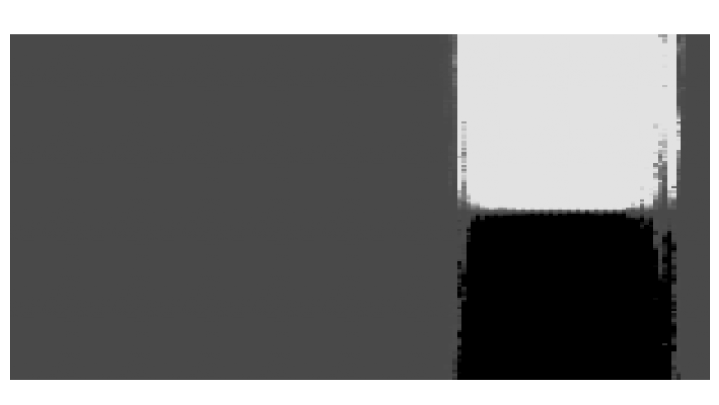

In [197]:
unseen_files = sorted(Path("../data/unseen").glob("*.png"))

# Proposed crop for this format
left = 170
top = 180
right = 860
bottom = 560

img = Image.open(unseen_files[0]).convert("L")
cropped = img.crop((left, top, right, bottom))

plt.figure(figsize=(10, 5))
plt.imshow(cropped, cmap="gray")
plt.axis("off")

(1024, 768)


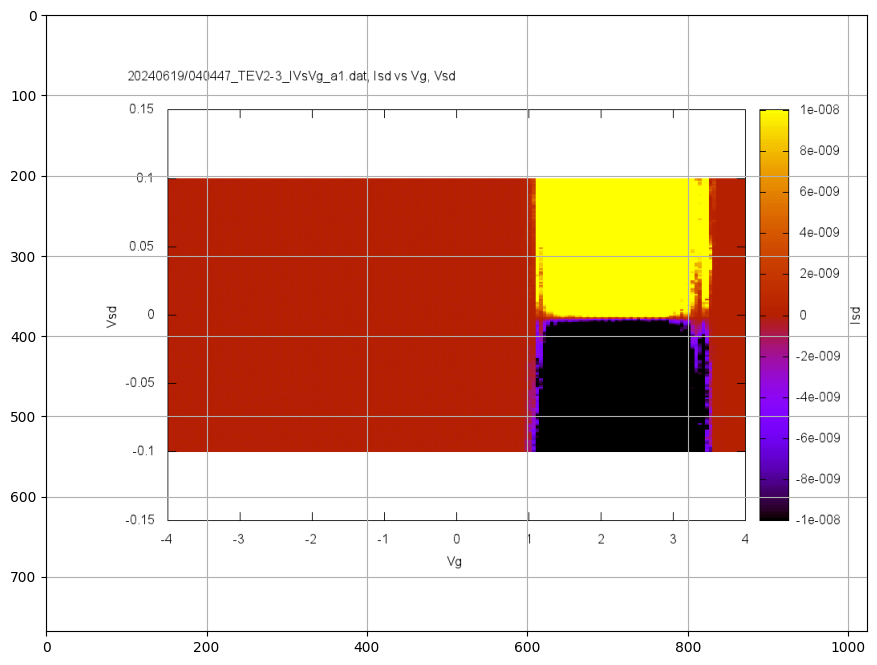

In [190]:
img = Image.open(unseen_files[0])

print(img.size)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.xlim(0, 1024)
plt.ylim(768, 0)
plt.grid()
plt.show()

In [219]:
unseen_dir = Path("../data/unseen")
processed_unseen_dir = Path("../data/unseen_processed")

processed_unseen_dir.mkdir(parents=True, exist_ok=True)

left = 170
top = 220
right = 860
bottom = 540

for i, f in enumerate(unseen_files, start=1):
    img = Image.open(f).convert("L")
    cropped = img.crop((left, top, right, bottom))

    output_path = processed_unseen_dir / f"image_{i:03d}.png"
    cropped.save(output_path)

print(f"Processed {len(unseen_files)} images.")

Processed 176 images.


In [220]:
from torch.utils.data import Dataset, DataLoader


class UnseenDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]

        image = Image.open(path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, path.name


unseen_processed_files = sorted(
    Path("../data/unseen_processed").glob("*.png")
)

unseen_dataset = UnseenDataset(
    unseen_processed_files,
    transform=eval_transform
)

unseen_loader = DataLoader(
    unseen_dataset,
    batch_size=16,
    shuffle=False
)

In [221]:
model_ft_aug.eval()

unseen_results = []

with torch.no_grad():
    for images, filenames in unseen_loader:
        outputs = model_ft_aug(images)
        probs = torch.sigmoid(outputs.squeeze(1))

        for filename, prob in zip(filenames, probs):
            probability = prob.item()

            unseen_results.append({
                "filename": filename,
                "prob_leakage": probability,
                "prediction": int(probability >= 0.67)
            })

unseen_results = pd.DataFrame(unseen_results)

print(f"Total images: {len(unseen_results)}")
print(
    unseen_results["prediction"]
    .value_counts()
    .sort_index()
)

Total images: 176
prediction
0    170
1      6
Name: count, dtype: int64


In [222]:
unseen_results.sort_values(
    "prob_leakage",
    ascending=False
)

,filename,prob_leakage,prediction
169,image_170.png,0.997021,1
168,image_169.png,0.997021,1
132,image_133.png,0.974903,1
133,image_134.png,0.974903,1
69,image_070.png,0.897948,1
...,...,...,...
127,image_128.png,0.000835,0
164,image_165.png,0.000574,0
165,image_166.png,0.000574,0
138,image_139.png,0.000313,0


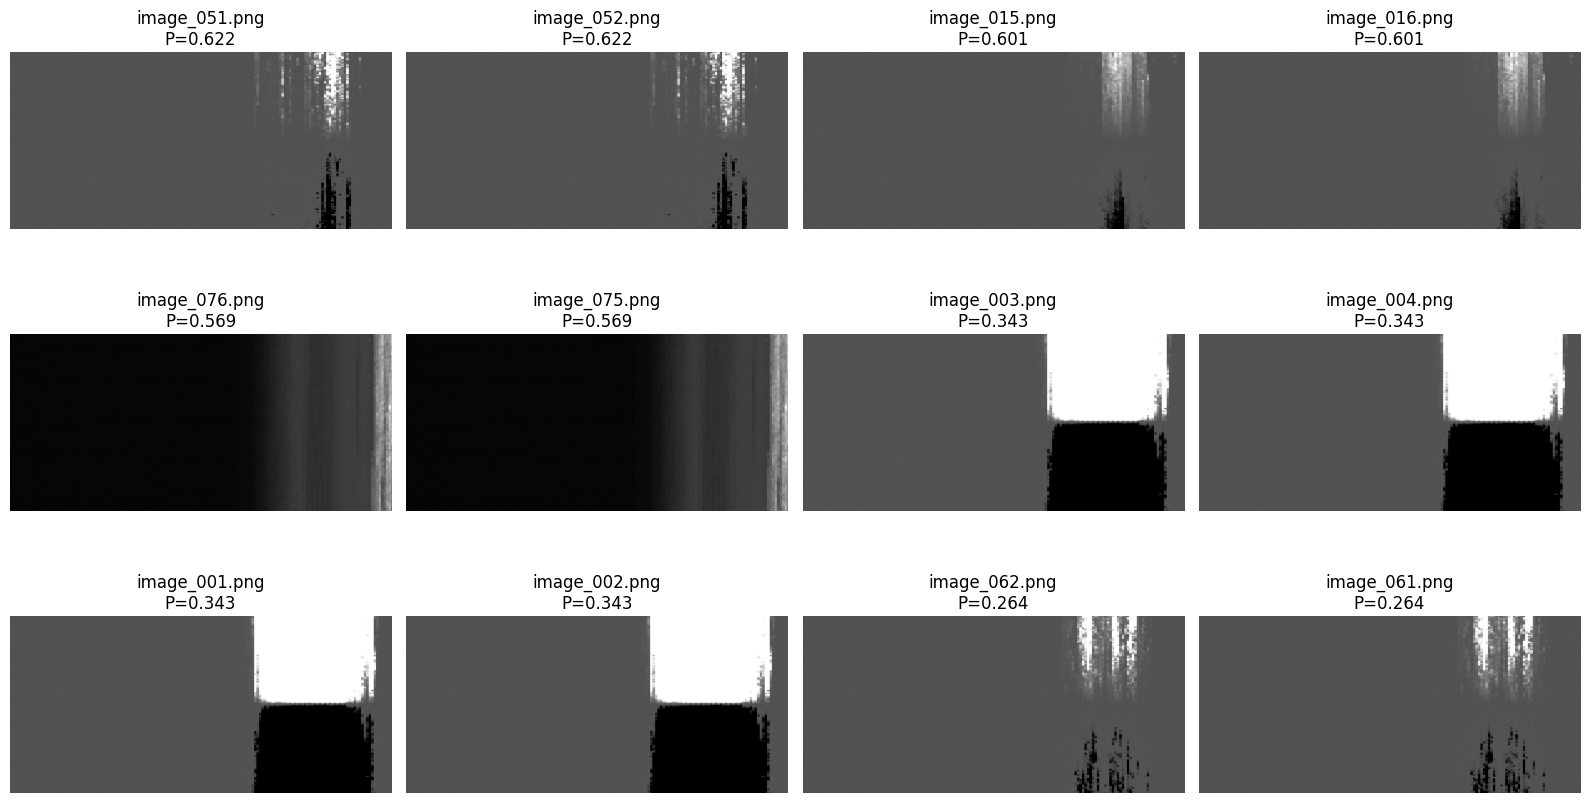

In [224]:
flagged = unseen_results[
    unseen_results["prediction"] == 0
].sort_values("prob_leakage", ascending=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for ax, (_, row) in zip(axes.flat, flagged.iterrows()):
    img = Image.open(
        Path("../data/unseen_processed") / row["filename"]
    )

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f'{row["filename"]}\nP={row["prob_leakage"]:.3f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Upon examination, there isn't any false positives, which is exactly the kind of things I'd like to avoid. There are however still some false negatives, but for my purpose, it doesn't really affect me

In [225]:
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    model_ft_aug.state_dict(),
    model_dir / "resnet18_gate_leakage_augmented.pth"
)

print("Saved:", model_dir / "resnet18_gate_leakage_augmented.pth")

Saved: ../models/resnet18_gate_leakage_augmented.pth


In [226]:
import json

config = {
    "architecture": "resnet18",
    "pretrained": "ImageNet",
    "trainable_layers": ["layer4", "fc"],
    "input_mode": "grayscale_replicated_to_3_channels",
    "input_size": [224, 224],
    "threshold": 0.67,
    "augmentation": "vertical_flip",
    "crop": {
        "left": 170,
        "top": 180,
        "right": 860,
        "bottom": 560
    }
}

with open(model_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "architecture": "resnet18",
  "pretrained": "ImageNet",
  "trainable_layers": [
    "layer4",
    "fc"
  ],
  "input_mode": "grayscale_replicated_to_3_channels",
  "input_size": [
    224,
    224
  ],
  "threshold": 0.67,
  "augmentation": "vertical_flip",
  "crop": {
    "left": 170,
    "top": 180,
    "right": 860,
    "bottom": 560
  }
}
